In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
import open_clip
import torch

from autoencoder.model import Autoencoder
from lerf_utils import relevancy_scores

In [49]:
# for hypernerf data dirs
data_root = Path("data/hypernerf/chickchicken")
rgb_root = data_root / "rgb/2x"
lang_root = data_root / "clip_features"

queries = [
    "chicken", "hand", "surface", "egg"
]
neutral_corpus = [
    "object",
    "things",
    "stuff",
    "texture"
]

ae_path = Path("autoencoder/ckpt/chickchicken_clip/best_ckpt.pth")

sam_level = 1

In [50]:
samples = [i.stem for i in sorted(rgb_root.glob("*.png"))]
samples[0:10]

['000001',
 '000002',
 '000003',
 '000004',
 '000005',
 '000006',
 '000007',
 '000008',
 '000009',
 '000010']

rgb (960, 536, 3) uint8
seg (960, 536) int32 [[62 62 62 62 62]
 [62 62 62 62 62]
 [62 62 62 62 62]
 [62 62 62 62 62]
 [62 62 62 62 62]]
feat (144, 512) float32


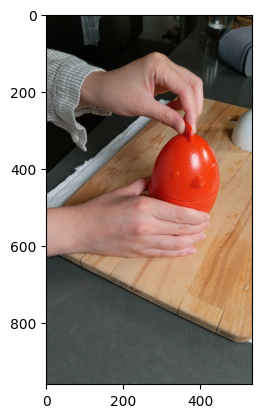

In [51]:
sample = samples[0]
rgb_path = rgb_root / f"{sample}.png"
seg_path = lang_root / f"{sample}_s.npy"
lfs_path = lang_root / f"{sample}_f.npy"

rgb = np.array(Image.open(rgb_path).convert("RGB"))
seg = np.load(seg_path)[sam_level].astype(np.int32)
feat = np.load(lfs_path)

print("rgb", rgb.shape, rgb.dtype)
print("seg", seg.shape, seg.dtype, seg[:5, :5])
print("feat", feat.shape, feat.dtype)
plt.imshow(rgb)

In [52]:
model, _, _ = open_clip.create_model_and_transforms('ViT-B-16', pretrained='laion2b_s34b_b88k')
tokenizer = open_clip.get_tokenizer('ViT-B-16')

with torch.no_grad(), torch.autocast("cuda"):
    text_feats = model.encode_text(tokenizer(queries))
    text_feats /= text_feats.norm(dim=-1, keepdim=True)
    text_feats = text_feats.detach().cpu().numpy()

    neutral_feats = model.encode_text(tokenizer(neutral_corpus))
    neutral_feats /= neutral_feats.norm(dim=-1, keepdim=True)
    neutral_feats = neutral_feats.detach().cpu().numpy()

chicken mean 0.1958527 std 0.013377972 min 0.16754152 max 0.23034662
hand mean 0.22061875 std 0.01749378 min 0.1758261 max 0.28206202
surface mean 0.18585676 std 0.018275145 min 0.1366154 max 0.22647496
egg mean 0.19395697 std 0.022230305 min 0.1536114 max 0.27859557


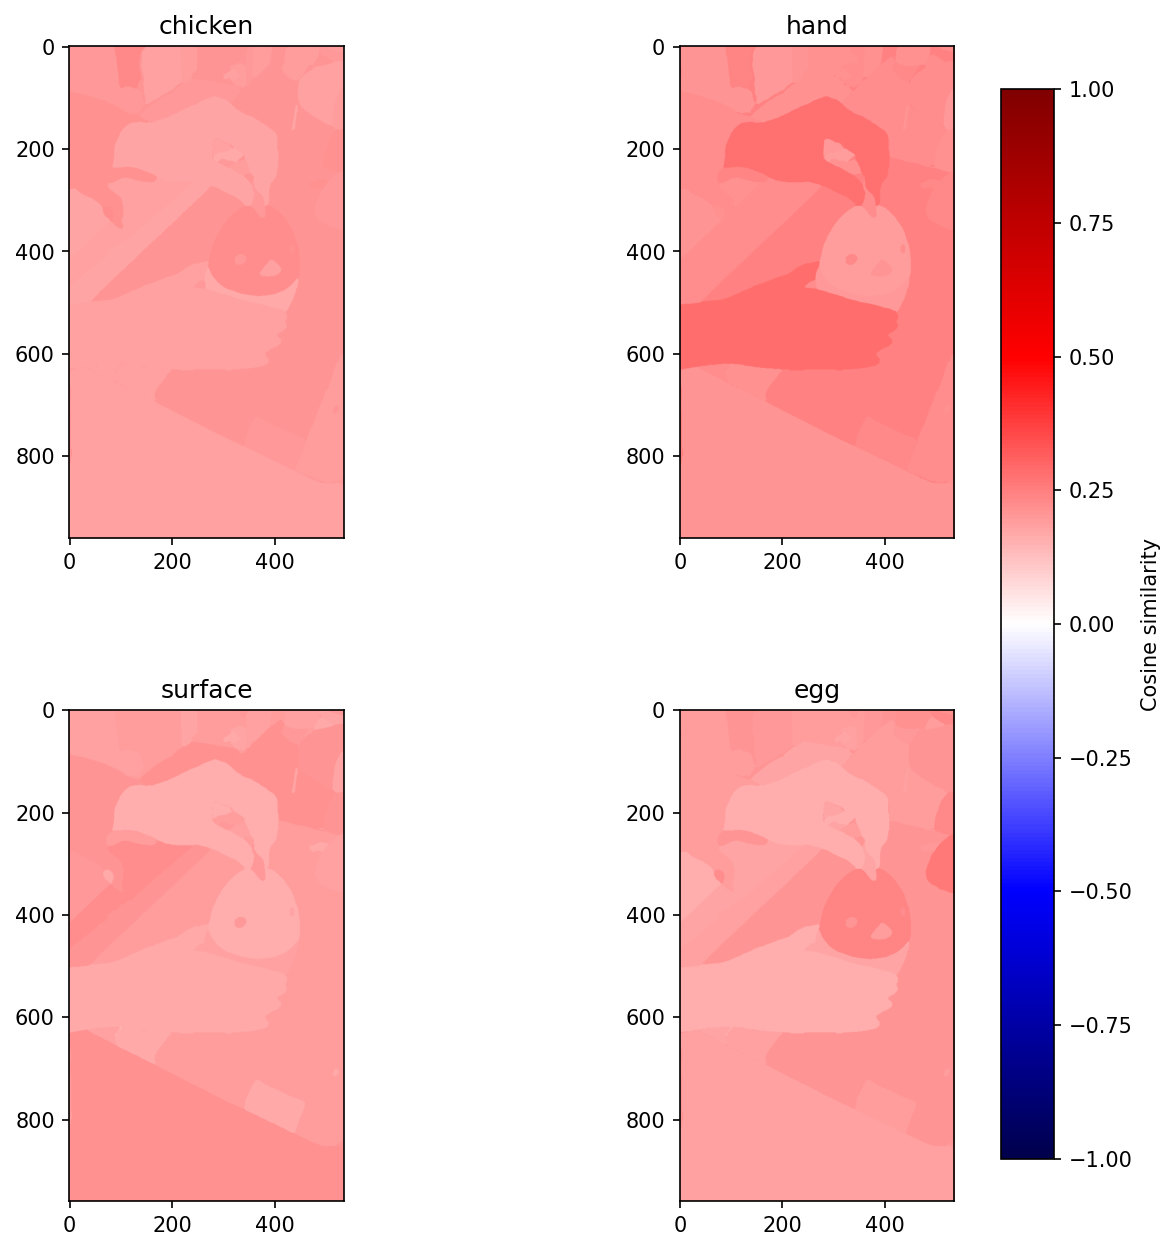

In [53]:
norm_feat = feat / np.linalg.norm(feat, axis=-1, keepdims=True)

cos_sim = text_feats @ norm_feat.T

norm = mcolors.Normalize(vmin=-1.0, vmax=1.0, clip=True)
cmap = mpl.colormaps['seismic']

ncols = min(2, len(queries))
nrows = int(np.ceil(len(queries) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), dpi=150)
axes = np.atleast_1d(axes).ravel()
used_axes = axes[:len(queries)]

# show grid of images with corresponding text
for i, q in enumerate(queries):
    feat_corr = cos_sim[i]
    feat_rgba = cmap(norm(feat_corr))
    feat_rgb = (feat_rgba[:, :3] * 255.0).astype(np.uint8)

    feat_img = feat_rgb[seg.reshape(-1)].reshape(*seg.shape, 3)

    print(q, "mean", feat_corr.mean(), "std", feat_corr.std(), "min", feat_corr.min(), "max", feat_corr.max())

    ax = axes[i]
    ax.imshow(feat_img)
    ax.set_title(q)

# hide any unused axes
for ax in axes[len(queries):]:
    ax.axis('off')

# increase spacing/borders between subplots
fig.subplots_adjust(wspace=0.35, hspace=0.35)

# add a shared colorbar (legend) for cosine similarity
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=used_axes, fraction=0.046, pad=0.04)
cbar.set_label("Cosine similarity")

plt.show()

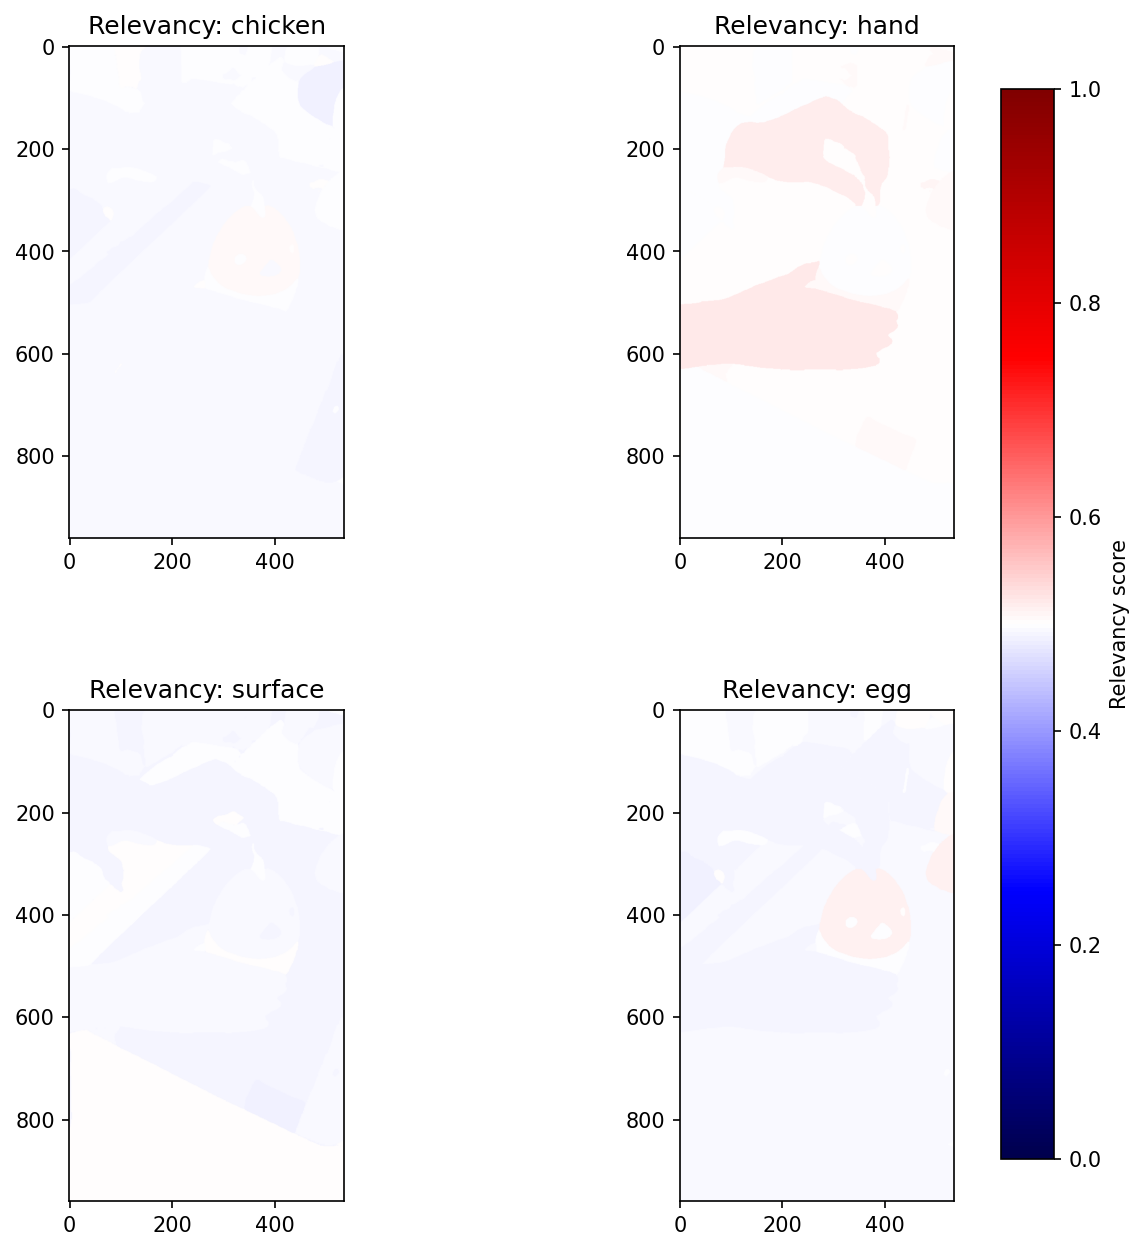

In [ ]:
relevancy = relevancy_scores(
    lang=norm_feat,
    query=text_feats,
    canon=neutral_feats,
)

score_norm = mcolors.Normalize(vmin=0.0, vmax=1.0, clip=True)
score_cmap = mpl.colormaps['seismic']

ncols = min(2, len(queries))
nrows = int(np.ceil(len(queries) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), dpi=150)
axes = np.atleast_1d(axes).ravel()
used_axes = axes[:len(queries)]

for i, q in enumerate(queries):
    feat_scores = relevancy[i]
    feat_rgba = score_cmap(score_norm(feat_scores))
    feat_rgb = (feat_rgba[:, :3] * 255.0).astype(np.uint8)

    feat_img = feat_rgb[seg.reshape(-1)].reshape(*seg.shape, 3)

    ax = axes[i]
    ax.imshow(feat_img)
    ax.set_title(f"Relevancy: {q}")

for ax in axes[len(queries):]:
    ax.axis('off')

fig.subplots_adjust(wspace=0.35, hspace=0.35)

sm = cm.ScalarMappable(norm=score_norm, cmap=score_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=used_axes, fraction=0.046, pad=0.04)
cbar.set_label("Relevancy score")

plt.show()

In [ ]:
# for future testing if ae makes them worse in case we find a bug in raw clip feats
ae = Autoencoder(
    encoder_hidden_dims=[256, 128, 64, 32, 3],
    decoder_hidden_dims=[16, 32, 64, 128, 256, 512],
    feature_dim=512,
).to("cuda")
ae.load_state_dict(torch.load(ae_path, map_location='cuda'))
ae.eval()